In [1]:
# import libraries
import cobra
import matplotlib.pyplot as plt
import scipy as sp
import numpy as np
import pandas as pd
from sklearn import decomposition
from sklearn import datasets
from sklearn.preprocessing import scale
from sklearn.linear_model import LinearRegression
import statsmodels
from scipy.stats import sem, t
from numpy import mean
from statsmodels.sandbox.stats.multicomp import multipletests
import seaborn as sns
from scipy.stats import hypergeom
%matplotlib inline

In [173]:
# Import differential flux analysis data
rxnlist=pd.read_csv('/Users/apple/Downloads/Script_CBM_and_Analysis/4.Analysis/KS_Test/Combined_sigFC_Results.csv')

In [173]:
# Import differential flux analysis data
rxnlist=pd.read_csv('/Users/apple/Downloads/Script_CBM_and_Analysis/4.Analysis/KS_Test/Combined_sigFC_Results.csv')

In [175]:
# Import subsystem file
subs=pd.read_csv('Recon3D_RxnID_Subsystem.csv')

In [177]:
# Pathway enrichment analysis

In [179]:
dataset=pd.DataFrame()
for path in subs['Var2'].unique():
    reaction_set=subs.loc[subs['Var2']==path,'Var1']
    rxn=reaction_set.reset_index(drop=True)
    df_temp=pd.DataFrame({path:rxn})
    dataset=pd.concat([dataset,df_temp],axis=1)

In [181]:
listSize=len(rxnlist)
listrxnSize=[]
setSize=[]
rxnSize=10600

for col in dataset.columns:
    df=pd.DataFrame({'Reaction':dataset[col]})
    out=df.merge(rxnlist)
    listrxnSize.append(len(out))
    setSize.append(len(dataset[col].dropna()))

hyperdata=pd.DataFrame({'Pathways':dataset.columns,'ListReactions':listrxnSize,'SetSize':setSize})

In [183]:
hits=hyperdata['ListReactions']
pool=hyperdata['SetSize']
allrxns=hyperdata['SetSize'].sum()
targetrxns=hyperdata['ListReactions'].sum()

In [185]:
allrxns

10600

In [187]:
pvalList=[]
for h,p in zip(hits,pool):
    rv=hypergeom(allrxns-p,p,targetrxns)
    pval=rv.pmf(h)
    pvalList.append(pval)

hyperdata['P-value']=pvalList
reject,padj,_,_=statsmodels.stats.multitest.multipletests(hyperdata['P-value'], alpha=0.05, method='fdr_bh', is_sorted=False, returnsorted=False)
hyperdata['P-valueadj']=padj
hyperdata['Reject']=reject

In [189]:
pvalList

[0.00984824223141406,
 0.7013869232946504,
 1.1080075593477106e-05,
 0.1426523895446533,
 4.3756359174732506e-07,
 5.634341989566506e-05,
 0.028656144854490265,
 3.569262155705124e-08,
 0.2418335086684529,
 0.01406148043773492,
 5.04624318496743e-08,
 0.3449180570682723,
 0.058370591084212595,
 8.000835069089755e-33,
 1.4867766310200688e-07,
 1.0372262065274647e-07,
 4.709382360540066e-06,
 0.2418335086684529,
 0.006896578999858933,
 0.004828986580631766,
 0.026624627238094077,
 0.01406148043773492,
 0.000979598551226291,
 5.780261575375537e-24,
 0.3449180570682723,
 0.0,
 1.8002334701429214e-37,
 4.26009810533379e-39,
 0.1120008555659905,
 0.0002778006817524196,
 0.006896578999858933,
 0.16407950576682354,
 0.005405093801123215,
 2.382563566553808e-13,
 5.04624318496743e-08,
 4.797612311566522e-05,
 8.536861551489689e-12,
 0.006896578999858933,
 0.2418335086684529,
 0.0011593577380859387,
 6.643572964545316e-05,
 0.49188432643284963,
 0.006896578999858933,
 0.1695370390301998,
 2.1219

In [191]:
targetrxns

3165

In [193]:
pval

0.1695370390301998

In [195]:
df = hyperdata.sort_values(by='ListReactions',ascending=False)

In [197]:
df

,Pathways,ListReactions,SetSize,P-value,P-valueadj,Reject
86,Transport,2187,3743,1.334023e-112,2.668045e-111,True
60,Nucleotide interconversion,194,164,0.000000e+00,0.000000e+00,True
22,Drug metabolism,152,573,9.795986e-04,2.448996e-03,True
26,Fatty acid oxidation,147,952,1.800233e-37,2.250292e-36,True
23,Eicosanoid metabolism,75,93,5.780262e-24,5.254783e-23,True
...,...,...,...,...,...,...
39,Heme synthesis,0,19,1.159358e-03,2.827702e-03,True
38,Heme degradation,0,4,2.418335e-01,2.748108e-01,False
37,Glyoxylate and dicarboxylate metabolism,0,14,6.896579e-03,1.253923e-02,True
36,Glycosphingolipid metabolism,0,71,8.536862e-12,5.021683e-11,True


In [199]:
df.to_csv("CD_Combined_Results_Pathway_enrichment.csv")

In [201]:
hyperdata_sig=hyperdata[(hyperdata['Reject']) & (hyperdata['ListReactions']!=0)]
hyperdata_sorted=hyperdata_sig.sort_values(by='P-valueadj',ascending=False)

In [207]:
hyperdata_sorted=hyperdata_sorted.drop([86],axis=0) #Remove transport reactions and exchange reactions

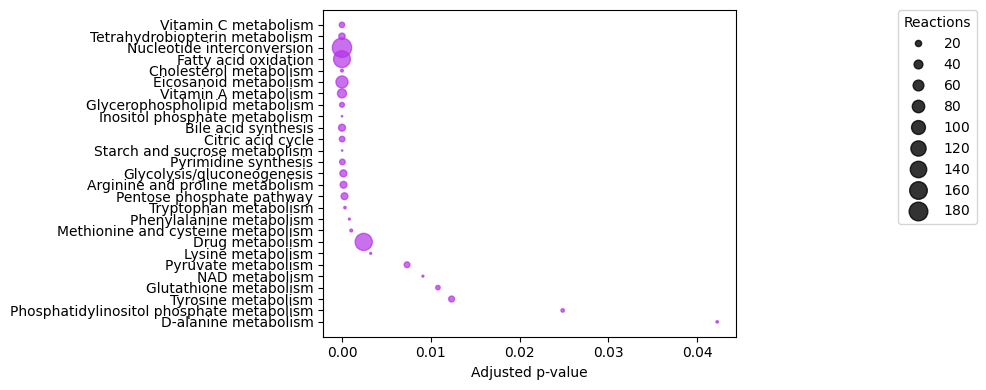

In [209]:
plt.figure(figsize=(14,4))

sc=plt.scatter(hyperdata_sorted['P-valueadj'],np.arange(0,len(hyperdata_sorted['Pathways'])),s=hyperdata_sorted['ListReactions'],color=(0.7,0.2,0.9,0.7))
plt.xlabel('Adjusted p-value')
plt.yticks(np.arange(0,len(hyperdata_sorted['Pathways'])),labels=hyperdata_sorted['Pathways'])
handles, labels = sc.legend_elements(prop="sizes", alpha=0.8)
plt.legend(handles, labels, bbox_to_anchor=(1.6,1.02),loc='upper right',title="Reactions")
# plt.grid(axis='y')
plt.tight_layout()
plt.savefig('CD_Combined_Results_R_pic_sigFC1.png',dpi=600)